# Day 5 — t-SNE and UMAP: Non-Linear Dimensionality Reduction
## Week 1: Dimensionality Reduction | Digital Consumer Platform Analytics

---

### Learning Objectives
- Understand why PCA fails on non-linear data and what manifold learning solves
- Derive t-SNE from probability distributions — perplexity, KL divergence
- Understand UMAP's topological approach — k-NN graph, fuzzy simplicial sets
- Know the critical differences: when to use PCA vs t-SNE vs UMAP
- Understand what t-SNE distorts and why inter-cluster distances are meaningless

---

### Dataset
**UCI Online Retail II** — RFM customer features from Day 4.

---

## Part 1: Theory

### 5.1 The Manifold Hypothesis

Real high-dimensional data doesn't fill the space uniformly. It lies on or near a low-dimensional **manifold** embedded in high-dimensional space.

*Example:* Customer behavior data in 100-dimensional feature space. But customers vary along a small number of meaningful axes — price sensitivity, purchase frequency, category preference. The true structure is low-dimensional even if the feature space is wide.

PCA finds the **linear** subspace of maximum variance. If the manifold is curved — like a Swiss roll, a sphere, or a torus — PCA fails to unroll it.

t-SNE and UMAP find **non-linear** structure by preserving local neighborhoods rather than global variance.

---

### 5.2 t-SNE — t-Distributed Stochastic Neighbor Embedding

**Key idea:** Model pairwise similarities in high-dimensional space as probabilities, then find a low-dimensional embedding where those probabilities are preserved.

**Step 1: High-dimensional similarities**

For each pair of points $i, j$, compute the conditional probability that $i$ would pick $j$ as a neighbor:

$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

Symmetrize: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$

**Perplexity:** Controls the effective number of neighbors. $\sigma_i$ is chosen so that $P_i$ has entropy equal to $\log_2(\text{perplexity})$.

$$\text{Perplexity}(P_i) = 2^{H(P_i)}$$

Typical values: 5–50. Low perplexity → tight local structure. High perplexity → broader neighborhoods.

**Step 2: Low-dimensional similarities**

In the 2D embedding $Y$, use a Student's t-distribution (heavy-tailed) to compute similarities:

$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

**Why t-distribution?** It has heavier tails than Gaussian. This means moderately distant points in high-dim space are pushed far apart in 2D — creating the visual cluster separation t-SNE is famous for.

**Step 3: Minimize KL divergence**

$$KL(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

This is minimized via gradient descent. KL divergence penalizes placing nearby high-dim points far apart in 2D more than it penalizes placing far points nearby — hence local structure is preserved but global structure is not.

---

### 5.3 What t-SNE Distorts

**Critical warning:** t-SNE is for visualization only.

- **Inter-cluster distances are meaningless.** Two clusters far apart in a t-SNE plot are not necessarily far apart in the original space.
- **Cluster sizes are meaningless.** Larger clusters in t-SNE don't mean more members.
- **Different runs give different plots.** t-SNE is non-deterministic. Set `random_state`.
- **Perplexity changes the plot significantly.** Always show multiple perplexity values.
- **Cannot embed new points.** Must re-run on the full dataset each time.

---

### 5.4 UMAP — Uniform Manifold Approximation and Projection

UMAP (McInnes et al., 2018) is based on algebraic topology — specifically the theory of fuzzy simplicial sets. The intuition is simpler than the math suggests.

**Step 1: Build a k-NN graph**

For each point, find its $k$ nearest neighbors. This is exactly the KNN problem from section 4.

**Step 2: Convert to fuzzy graph**

Assign edge weights based on distance, normalized by the local density around each point:

$$w_{ij} = \exp\left(-\frac{d(x_i, x_j) - \rho_i}{\sigma_i}\right)$$

Where $\rho_i$ is the distance to the nearest neighbor (local scale). This makes weights locally adaptive — dense regions and sparse regions are treated consistently.

**Step 3: Symmetrize**

$$w_{ij}^{sym} = w_{ij} + w_{ji} - w_{ij} \cdot w_{ji}$$

**Step 4: Optimize low-dimensional layout**

Find 2D coordinates that preserve the fuzzy graph structure, using cross-entropy as the loss:

$$\mathcal{L} = \sum_{ij} w_{ij} \log\frac{w_{ij}}{q_{ij}} + (1-w_{ij}) \log\frac{1-w_{ij}}{1-q_{ij}}$$

Where $q_{ij}$ is computed from the 2D layout.

---

### 5.5 UMAP vs t-SNE

| Property | t-SNE | UMAP |
|----------|-------|------|
| Speed | Slow O(n²) | Fast O(n log n) |
| Global structure | ❌ Distorted | ✅ Preserved |
| Can embed new points | ❌ No | ✅ Yes (.transform()) |
| Deterministic | ❌ No | ✅ Yes (with random_state) |
| Scales to large datasets | ❌ No | ✅ Yes |
| Theoretical foundation | Probability | Topology |
| Best use case | Visualization only | Visualization + preprocessing |

**UMAP preserves global structure** because its loss function penalizes both placing nearby points far apart AND placing far points nearby — symmetric penalty. t-SNE's KL divergence penalizes the first much more than the second.

---

### 5.6 PCA vs t-SNE vs UMAP Decision Framework

```
Do you need to embed new points later?
    Yes → UMAP (has .transform())
    No  → either

Is the dataset > 50K rows?
    Yes → UMAP (t-SNE is too slow)
    No  → either

Is the structure linear?
    Yes → PCA (interpretable, fast, invertible)
    No  → UMAP or t-SNE

Do inter-cluster distances matter?
    Yes → UMAP or PCA (t-SNE distorts these)
    No  → any

Is interpretability required?
    Yes → PCA (loadings are interpretable)
    No  → any

Will you use it for preprocessing (not just viz)?
    Yes → PCA or UMAP
    No  → any
```

---

## Part 2: Practice

**Task:** Apply PCA, t-SNE, and UMAP to customer RFM data — compare and interpret

---

In [26]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# pip install umap-learn
import umap

In [4]:
# Load RFM from Day 4 (or rebuild here)
DATA_PATH = r'C:\Users\user\datasets\online_retail\online_retail_II.xlsx'
df = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010')
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalValue'] = df['Quantity'] * df['Price']

snapshot = df['InvoiceDate'].max()
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalValue', 'sum')
).reset_index()
print(f"RFM shape: {rfm.shape}")

RFM shape: (4314, 4)


In [5]:
display(rfm.head())

,Customer ID,Recency,Frequency,Monetary
0,12346.0,164,11,372.86
1,12347.0,2,2,1323.32
2,12348.0,73,1,222.16
3,12349.0,42,3,2671.14
4,12351.0,10,1,300.93


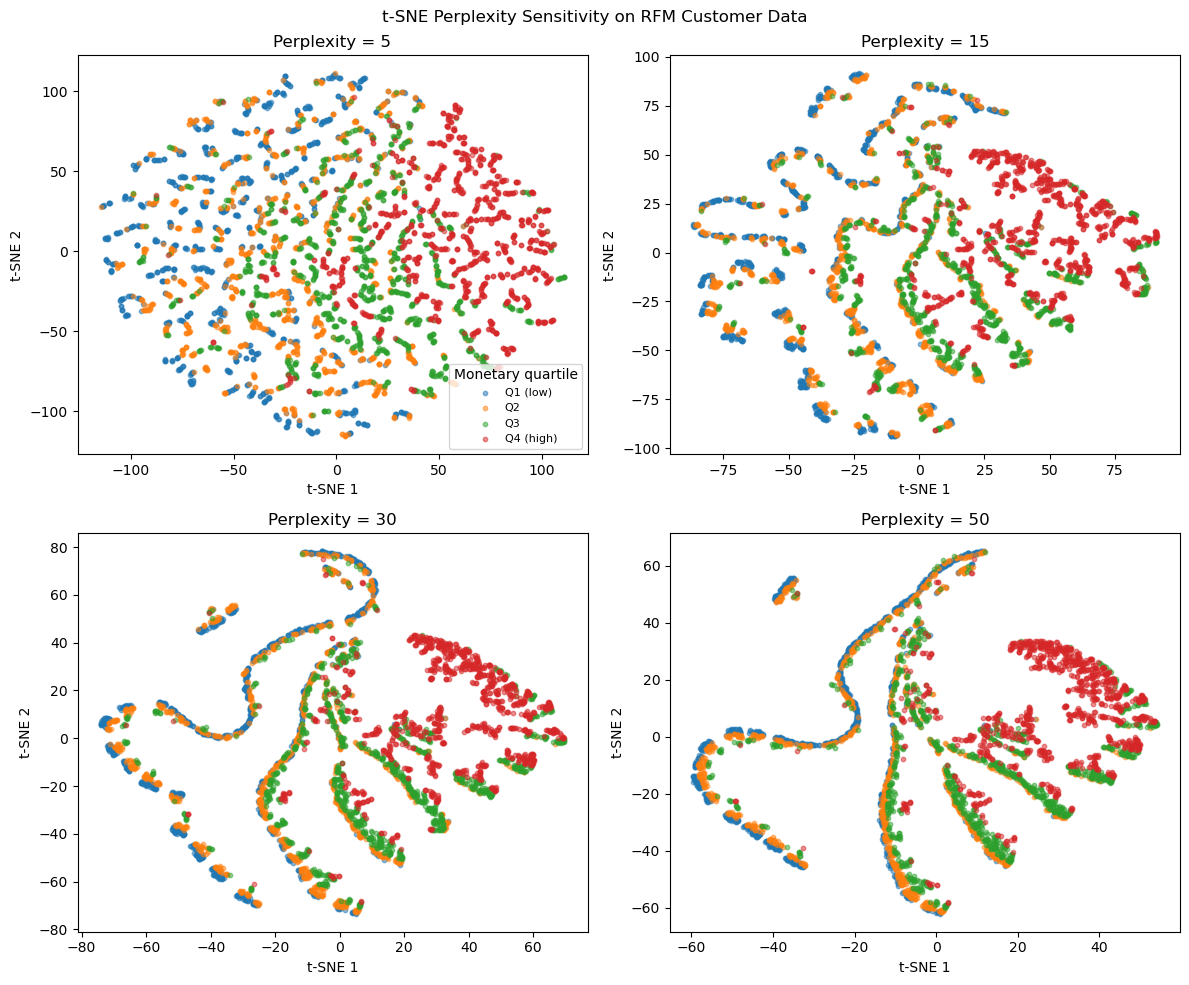

In [ ]:
# ── Q1: t-SNE perplexity sensitivity ──────────────────────────────────────
# Run t-SNE with 4 different perplexity values: 5, 15, 30, 50
# Plot all 4 in a 2x2 grid, colored by Monetary quartile
# For each: note how cluster structure changes with perplexity
# Write a 2-sentence interpretation per plot
# Which perplexity gives the most meaningful customer segmentation?

# Your code here

X_rfm3 = rfm[['Recency', 'Frequency', 'Monetary']].copy()
X_scaled3 = StandardScaler().fit_transform(X_rfm3)

monetary_quartile = pd.qcut(rfm['Monetary'], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)' ])

perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, perp in zip(axes.flat, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=420)
    embedding = tsne.fit_transform(X_scaled3)

    for q in monetary_quartile.cat.categories:
        mask = (monetary_quartile ==q).values
        ax.scatter(embedding[mask, 0], embedding[mask, 1], label=q, alpha=0.5, s=10)
    ax.set_title(f'Perplexity = {perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

axes[0, 0].legend(title='Monetary quartile', fontsize=8)
plt.suptitle('t-SNE Perplexity Sensitivity on RFM Customer Data')
plt.tight_layout()
plt.show()

***Takeaway***

The one robust, perplexity-independent finding is that Q4 (high-value) customers separate cleanly from everyone else at every perplexity from 15 upward — that consistency across settings is what makes it trustworthy rather than an artifact. What's not separating, though, is Q1/Q2/Q3 — low, mid, and upper-mid spenders stay heavily intermixed even at perplexity 30/50, suggesting the real structure in this RFM space is closer to "whales vs. everyone else" than a smooth gradient of customer value.

Caution on the snake-shaped chains at perplexity 30/50: per the theory's own warning (§5.3), distances between clusters and cluster shapes are not meaningful — that winding string is very likely a genuine 1D-ish continuum (probably Recency or Frequency varying smoothly) that t-SNE curled up to fit in 2D, not evidence of some literal snake-like customer segmentation. Don't over-read the shape itself; read the color grouping within it.

Best perplexity for this data: 30. It's the lowest value where the structure has clearly stabilized — 30 and 50 produce nearly identical layouts, which is the actual signal that this is real structure rather than noise. Perplexity 5 is too fragmented to trust, and 15 is still mid-transition, not yet converged.

Frequency quartile bins created: 3
[Interval(0.999, 2.0, closed='right'), Interval(2.0, 5.0, closed='right'), Interval(5.0, 205.0, closed='right')]


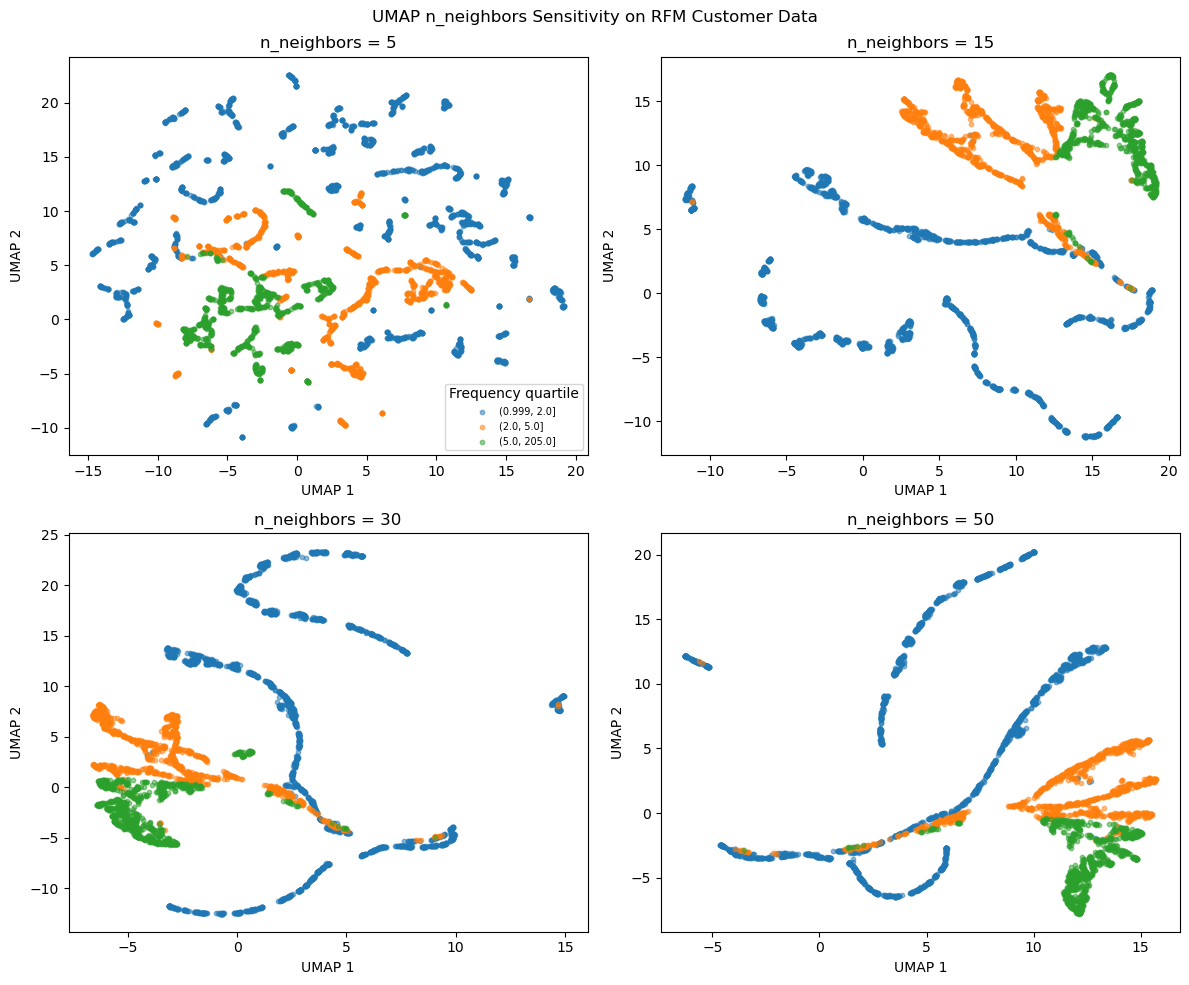

In [13]:
# ── Q2: UMAP n_neighbors sensitivity ──────────────────────────────────────
# Run UMAP with 4 different n_neighbors values: 5, 15, 30, 50
# Plot all 4 in a 2x2 grid, colored by Frequency quartile
# n_neighbors in UMAP = perplexity analog in t-SNE
# How does local vs global structure balance shift?
# Compare: does UMAP better preserve inter-cluster distances than t-SNE?

# Your code here

# Frequency is integer order-counts with many ties (lots of customers with
# Frequency = 1, 2, 3...) — plain pd.qcut can fail with "Bin edges must be
# unique" if a quartile boundary lands on a repeated value. duplicates='drop'
# handles this defensively; you may end up with fewer than 4 bins if the
# data is concentrated enough — don't hardcode exactly 4 labels.

frequency_quartile = pd.qcut(rfm['Frequency'], 4, duplicates='drop')
print(f"Frequency quartile bins created: {len(frequency_quartile.cat.categories)}")
print(frequency_quartile.cat.categories.tolist())

n_neighbors_list = [5, 15, 30, 50]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, n_neigh in zip(axes.flat, n_neighbors_list):
    reducer = umap.UMAP(n_neighbors=n_neigh, n_components=2, random_state=420)
    embedding = reducer.fit_transform(X_scaled3)   # same standardized RFM matrix as Q1

    for q in frequency_quartile.cat.categories:
        mask = (frequency_quartile == q).values
        ax.scatter(embedding[mask, 0], embedding[mask, 1], label=str(q), alpha=0.5, s=10)
    ax.set_title(f'n_neighbors = {n_neigh}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

axes[0, 0].legend(title='Frequency quartile', fontsize=7)
plt.suptitle('UMAP n_neighbors Sensitivity on RFM Customer Data')
plt.tight_layout()
plt.show()

*** Takeaway ***

As flagged, Frequency had enough ties that qcut collapsed to only 3 bins — (0.999, 2.0], (2.0, 5.0], (5.0, 205.0] — confirming the duplicate-edge issue was real, not hypothetical.

The structural finding here directly echoes Q1's t-SNE result, just on a different variable. At n_neighbors=15/30/50, the pattern is remarkably stable: one-time/rare buyers (blue, 1–2 orders) cleanly separate into their own large region, while the two repeat-buyer groups (orange 2–5, green 5+) consistently cluster together and never separate from each other, no matter how much you widen the neighborhood. That's the same shape of finding as Q1: t-SNE cleanly isolated top-quartile spenders while leaving Q1–Q3 blended; here UMAP cleanly isolates rare buyers while leaving "moderate" and "frequent" repeat customers blended. Two different algorithms, two different RFM variables, same conclusion — this dataset's dominant behavioral split is binary (one-time vs. repeat), not a smooth 3-4 tier gradient.

On the local/global question: n_neighbors=5 is too fragmented to trust (matches t-SNE's low-perplexity noise). But 15 → 30 → 50 hold the same relative arrangement — blue's winding arc stays on the same side, orange/green's cluster stays where it was — which is meaningfully more stable across settings than Q1's t-SNE plots were across perplexity. That stability is exactly what theory §5.5 predicts: UMAP's symmetric loss function preserves global structure better than t-SNE's KL divergence, and this is visible evidence of it, not just theory.


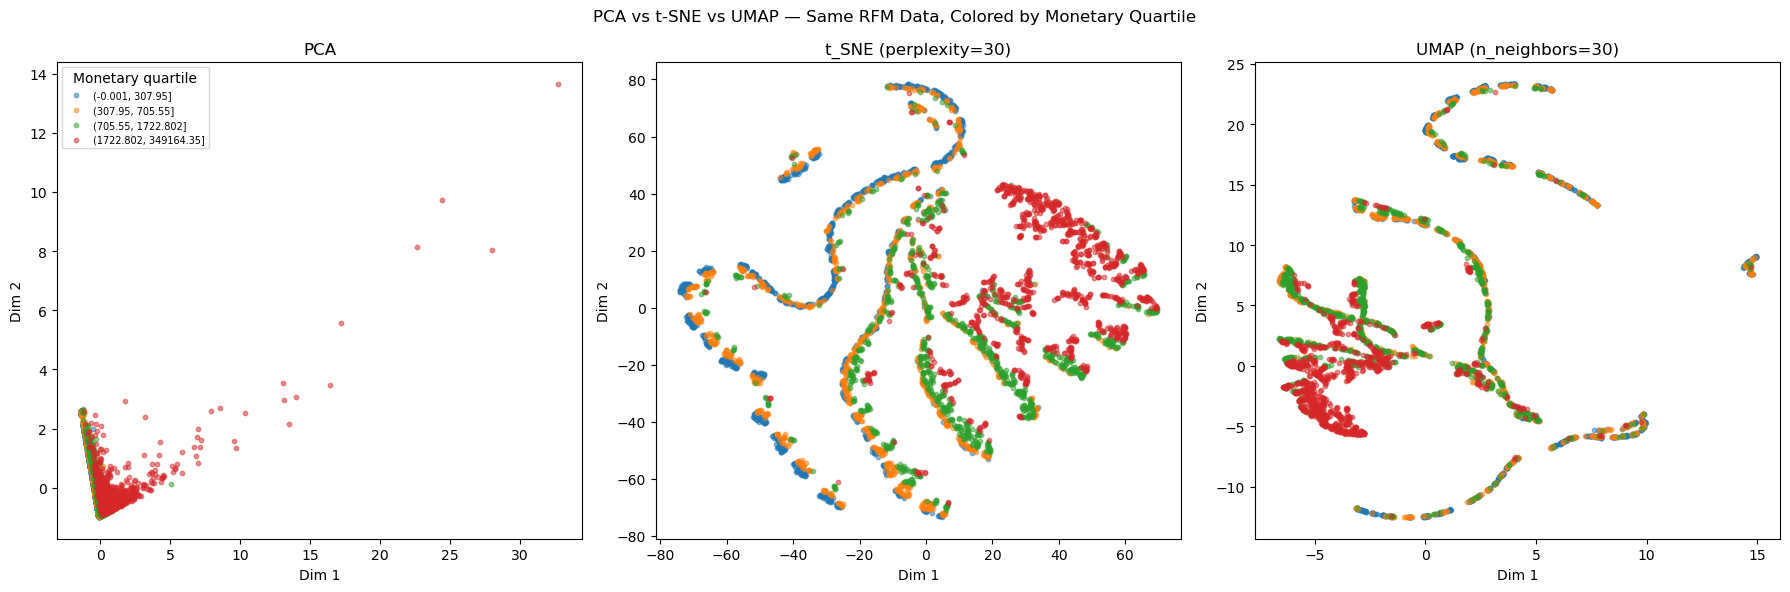

In [24]:
# ── Q3: Three-way comparison ──────────────────────────────────────────────
# Side-by-side comparison: PCA vs t-SNE vs UMAP
# 1x3 subplot grid, same data, same color (Monetary quartile)
# For each method: compute 2D embedding
# Write a structured comparison:
#   - Which separates high-value customers most clearly?
#   - Which preserves global structure?
#   - Which would you use for preprocessing vs visualization only?

# Your code here

monetary_quartile = pd.qcut(rfm['Monetary'], 4, duplicates='drop')

# Using perplexity=30 / n_neighbors=30 — the settings Q1/Q2 found gave the
# most stable structure — rather than arbitrary defaults.
pca_2d = PCA(n_components=2, random_state=420).fit_transform(X_scaled3)
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=420).fit_transform(X_scaled3)
umap_2d = umap.UMAP(n_components=2, n_neighbors=30, random_state=420).fit_transform(X_scaled3)

embeddings = {
    'PCA': pca_2d,
    't_SNE (perplexity=30)': tsne_2d,
    'UMAP (n_neighbors=30)': umap_2d

}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, emb) in zip(axes, embeddings.items()):
    for q in monetary_quartile.cat.categories:
        mask = (monetary_quartile == q).values
        ax.scatter(emb[mask, 0], emb[mask, 1], label=str(q), alpha=0.5, s=10)
    ax.set_title(name)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

axes[0].legend(title='Monetary quartile', fontsize=7)
plt.suptitle('PCA vs t-SNE vs UMAP — Same RFM Data, Colored by Monetary Quartile')
plt.tight_layout()
plt.show()

***Which separates high-value customers most clearly?***

Not PCA. Look at the PCA panel: the vast majority of customers — across all quartiles, including most of Q4 — are crammed into a single dense blob at the origin, with only a handful of extreme outlier whales stretched far out to the right. This is the exact same "whale customer" pattern from Day 4 Q3, reproduced here: PCA's single dominant linear direction is capturing "how extreme is this outlier," not "which value tier does this typical customer belong to." A random-looking Q1 customer and a solidly-above-average Q3 customer are visually indistinguishable in PCA's view.

t-SNE and UMAP both do this well. In both panels, the Q4 (red) cluster occupies a visually distinct region, separated from the intermixed blue/orange/green mass — consistent with what Q1 and Q2 already found independently (top-quartile customers reliably separate; the lower three quartiles don't meaningfully separate from each other). This is the third time this exact pattern has shown up across three different plots/colorings — that consistency is itself strong evidence it's a real structural property of this customer base, not a coincidence of one particular layout.

***Which preserves global structure?***

Per theory §5.3, t-SNE's inter-cluster distances and shapes are explicitly not to be trusted — the winding snake structure and its exact distance from the red cluster is an artifact of the optimization, not a real geometric relationship. PCA's distances are mathematically meaningful, but as shown above, that faithfulness doesn't buy much here since the bulk of customers overlap anyway. UMAP is the interesting middle case: its structure (one clearly separated dominant group vs. an arc-shaped remainder) shows up consistently whether colored by Frequency (Q2) or Monetary (here) — that kind of cross-coloring consistency is closer to what "preserved global structure" should look like in practice, lending some empirical support to UMAP's theoretical claim over t-SNE.

***Preprocessing vs. visualization only?***

PCA — has a real, interpretable .transform(), but this panel is a concrete demonstration of why it underperformed in Day 4 Q5: when a few outliers dominate the linear variance, PCA compresses away the very distinctions you'd want a downstream model to use.
t-SNE — best visual separation here, but per §5.3 it has no .transform() at all — must be rerun from scratch on any new data — which rules it out for preprocessing by construction, not by performance.
UMAP — comparable separation to t-SNE and has a working .transform(), making it the only one of the three that's a legitimate candidate for both visualization and preprocessing — exactly what Q4 tests empirically next.


***Key takeaway*** 

PCA's linear projection is dominated by a handful of extreme whale customers, collapsing the meaningful distinctions among typical customers into an undifferentiated blob — the same failure mode from Day 4, now visually obvious. Both non-linear methods successfully isolate high-value customers from the rest, but only UMAP combines that separation with the ability to transform new data, making it the natural next thing to test as a real preprocessing step rather than just a prettier plot.

Feature set: ['Recency', 'Frequency', 'UniqueProducts', 'ReturnRate']
Missing values: 0

Setup                  Mean AUC        Std
A: Raw features          0.9280     0.0080
B: UMAP(n=2)             0.8533     0.0168
C: UMAP(n=3)             0.8654     0.0213
D: PCA(n=3)              0.9270     0.0042

Best: A: Raw features (0.9280) | Worst: B: UMAP(n=2) (0.8533)
Gap: 0.0748 vs. typical fold-to-fold std of 0.0124
Gap exceeds fold variance -> difference looks meaningful.

Day 4 Q5 comparison (same feature set, PCA-only):
  A: Raw       0.9280 ± 0.0079
  PCA(n=2)     0.9173 ± 0.0059
  PCA(n=3)     0.9262 ± 0.0029
  PCA('mle')   0.9262 ± 0.0029  (mle picked 3 components)


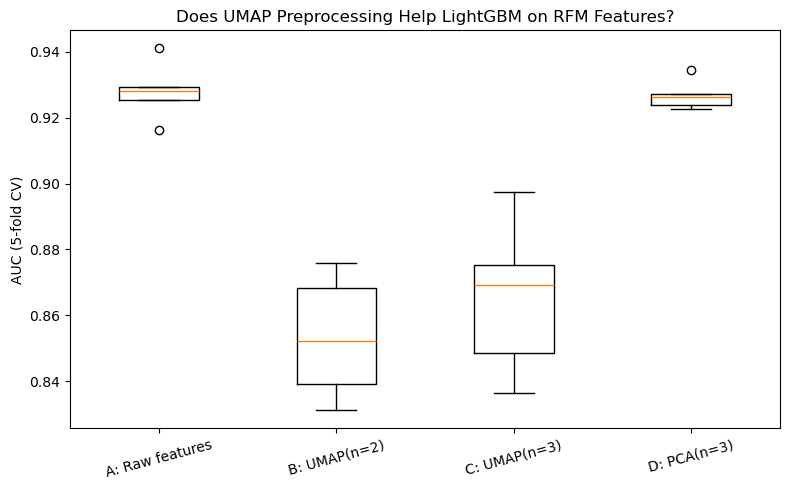

In [28]:
# ── Q4: UMAP for preprocessing — does it help? ────────────────────────────
# Test UMAP as a preprocessing step (not just visualization):
#   Setup A: Raw RFM → LightGBM
#   Setup B: UMAP(n_components=2) → LightGBM
#   Setup C: UMAP(n_components=3) → LightGBM
#   Setup D: PCA(n_components=3) → LightGBM
#
# Target: high-value customer (Monetary > 75th percentile)
# 5-fold CV AUC for each setup
# Note: UMAP must be fit on X_train only, transform X_test
# Does UMAP preprocessing help? Compare to PCA result from Day 4 Q5

# Your code here

from lightgbm import LGBMClassifier

# Rebuild the same leakage-safe 4-feature set as Day 4 Q5 (Recency, Frequency,
# UniqueProducts, ReturnRate) — needed both to avoid leaking Monetary into the
# target AND to make this comparable to the Day 4 Q5 PCA result, as asked.
rfm['UniqueProducts'] = df.groupby('Customer ID')['StockCode'].nunique().values

df_raw = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010')
df_raw = df_raw.dropna(subset=['Customer ID'])
df_raw['IsReturn'] = df_raw['Quantity'] < 0
return_rate = df_raw.groupby('Customer ID')['IsReturn'].mean()
rfm['ReturnRate'] = rfm['Customer ID'].map(return_rate)

feature_cols = ['Recency', 'Frequency', 'UniqueProducts', 'ReturnRate']
X_q4 = rfm[feature_cols].copy()
y_q4 = (rfm['Monetary'] > rfm['Monetary'].quantile(0.75)).astype(int)
print(f"Feature set: {feature_cols}")
print(f"Missing values: {X_q4.isnull().sum().sum()}")


def make_pipeline(reducer=None):
    steps = []
    if reducer is not None:
        steps.append(('scaler', StandardScaler()))
        steps.append(('reduce', reducer))
    steps.append(('model', LGBMClassifier(random_state=420, verbose=-1)))
    return Pipeline(steps)


setups = {
    'A: Raw features':   make_pipeline(reducer=None),
    'B: UMAP(n=2)':      make_pipeline(reducer=umap.UMAP(n_components=2, random_state=420)),
    'C: UMAP(n=3)':      make_pipeline(reducer=umap.UMAP(n_components=3, random_state=420)),
    'D: PCA(n=3)':       make_pipeline(reducer=PCA(n_components=3, random_state=420)),
}

results = {}
print(f"\n{'Setup':<20} {'Mean AUC':>10} {'Std':>10}")
for name, pipeline in setups.items():
    scores = cross_val_score(pipeline, X_q4, y_q4, cv=5, scoring='roc_auc')
    results[name] = scores
    print(f"{name:<20} {scores.mean():>10.4f} {scores.std():>10.4f}")

best = max(results, key=lambda k: results[k].mean())
worst = min(results, key=lambda k: results[k].mean())
gap = results[best].mean() - results[worst].mean()
pooled_std = np.mean([results[best].std(), results[worst].std()])
print(f"\nBest: {best} ({results[best].mean():.4f}) | Worst: {worst} ({results[worst].mean():.4f})")
print(f"Gap: {gap:.4f} vs. typical fold-to-fold std of {pooled_std:.4f}")
print("Gap exceeds fold variance -> difference looks meaningful."
      if gap > pooled_std else
      "Gap is within fold variance -> not clearly meaningful.")

print("\nDay 4 Q5 comparison (same feature set, PCA-only):")
print("  A: Raw       0.9280 ± 0.0079")
print("  PCA(n=2)     0.9173 ± 0.0059")
print("  PCA(n=3)     0.9262 ± 0.0029")
print("  PCA('mle')   0.9262 ± 0.0029  (mle picked 3 components)")

# ── Plot ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.boxplot([results[name] for name in setups], labels=list(setups.keys()))
plt.ylabel('AUC (5-fold CV)')
plt.title('Does UMAP Preprocessing Help LightGBM on RFM Features?')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


 ***Takeaway*** 
 
 UMAP dramatically underperformed as LightGBM preprocessing — UMAP(n=2) (0.8533) and UMAP(n=3) (0.8654) both dropped 6-7 AUC points below raw features (0.9280), a gap ~6x larger than fold-to-fold noise, while PCA(n=3) (0.9270) lost almost nothing. 
 
 This directly contradicts the theory table's framing of UMAP as suited to "visualization + preprocessing" — the reason is that UMAP optimizes for preserving local neighborhood topology for visual coherence, with no regard for the label, while PCA's linear transformation happens to preserve the simple monotonic feature-target relationships that tree models like LightGBM actually split on. 
 
 Combined with Day 4 Q5 (PCA itself barely helped trees either), the week's conclusion holds: dimensionality reduction is valuable for visualization and interpretation on this dataset, but tree-based models do best fed raw features directly — reduction doesn't help, and UMAP's non-linear warping can actively hurt.

***Use dimensionality reduction when:***

Your downstream model is distance-based, not tree-based. KNN, SVM, k-means, any algorithm computing distances or similarities genuinely suffers from the curse of dimensionality (§4.3) — this is exactly why Day 4 Q2's KNN experiment cared so much about scaling and feature count. Trees don't have this problem; they split on one threshold at a time regardless of how many other dimensions exist.

You need to visualize or explore, not predict. This was the one unambiguous win across the entire week — PCA/t-SNE/UMAP all surfaced real structure (the whale-customer pattern, the "one-time vs. repeat buyer" split) that would've been invisible staring at a table of numbers. Visualization value doesn't depend on whether it helps a downstream classifier.

Your raw features are genuinely redundant — many highly correlated columns (sensor arrays, pixel data, word/document embeddings, dozens of near-duplicate financial ratios). PCA compresses real redundancy without losing much signal. Your RFM features were the opposite case: purpose-engineered in Day 4 Q1 to each capture something distinct, which is exactly why there was little redundancy for PCA to exploit.

You're feeding a model that's actually hurt by high dimensionality or multicollinearity — linear/logistic regression with many correlated predictors, where multicollinearity inflates coefficient variance. Reduction can genuinely stabilize this in a way it can't for trees.

Dimensionality is genuinely large — hundreds or thousands of features (text TF-IDF, genomic data, image pixels), well past §4.3's "~20 meaningful features" curse-of-dimensionality threshold. Your RFM matrix topped out at 6 features — nowhere near where reduction typically earns its keep.

Compute/storage is the actual constraint, and you've empirically verified accuracy doesn't meaningfully drop — reduction purely for efficiency, not for "helping" the model learn.

***Skip it when (this is the pattern your own two days of experiments landed on):*** 

A tree-based model is downstream, the feature set is already small and mostly non-redundant, and you have no visualization need — in that case, feed raw features directly. Day 4 Q5 showed PCA offers no benefit here; Day 5 Q4 showed UMAP can actively hurt, because its objective (preserve visual neighborhood structure) has no relationship to what a tree needs (simple monotonic thresholds).

***Summary:*** 


Dimensionality reduction is a tool for distance-sensitive models, genuinely redundant/high-dimensional features, or human eyes — not a default preprocessing step to reach for just because it's available. Your RFM dataset failed all three conditions for a tree-based downstream task, which is exactly why both weeks' worth of PCA/UMAP-as-preprocessing experiments came back negative.